In [1]:
import os

print(os.getcwd())

C:\Users\Ruchita


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/Ruchita/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)
df.info()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
for column in df.columns:
    print(column, ":", df[column].nunique())

customerID : 7043
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 73
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1585
TotalCharges : 6531
Churn : 2


In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
print(df['Contract'].value_counts())
print(df['InternetService'].value_counts())
print(df['PaymentMethod'].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/Ruchita/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)
df.info()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df = df.dropna(subset=['TotalCharges'])

In [12]:
print(df.shape)
print(df.isnull().sum().sum())

(7032, 21)
0


In [13]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [14]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 Year'
    elif tenure <= 24:
        return '1-2 Years'
    elif tenure <= 48:
        return '2-4 Years'
    else:
        return '4+ Years'

df['TenureGroup'] = df['tenure'].apply(tenure_group)
df['TenureGroup'].value_counts()

TenureGroup
4+ Years     2239
0-1 Year     2175
2-4 Years    1594
1-2 Years    1024
Name: count, dtype: int64

In [15]:
df['CustomerValue'] = df['MonthlyCharges'] * df['tenure']
df[['MonthlyCharges', 'tenure', 'CustomerValue']].head()

,MonthlyCharges,tenure,CustomerValue
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [16]:
print(df[['tenure', 'TenureGroup', 'MonthlyCharges', 'CustomerValue', 'Churn']].head())

   tenure TenureGroup  MonthlyCharges  CustomerValue  Churn
0       1    0-1 Year           29.85          29.85      0
1      34   2-4 Years           56.95        1936.30      0
2       2    0-1 Year           53.85         107.70      1
3      45   2-4 Years           42.30        1903.50      0
4       2    0-1 Year           70.70         141.40      1


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
print(df['Churn'].value_counts())

print(df['Churn'].value_counts(normalize=True) * 100)

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


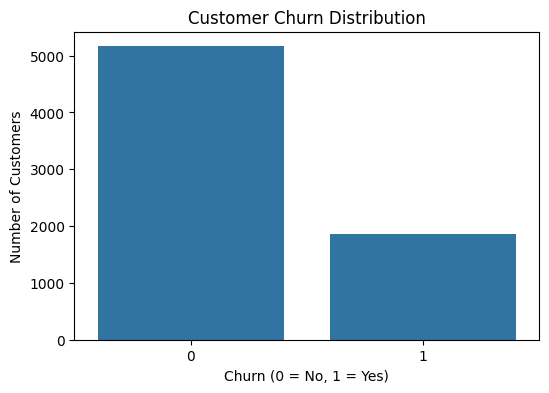

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

plt.show()

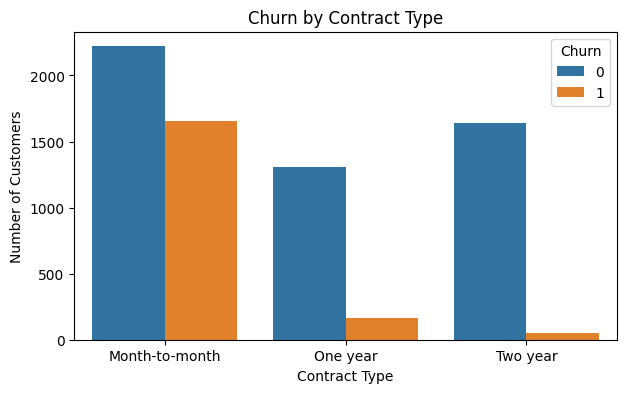

In [20]:
plt.figure(figsize=(7,4))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

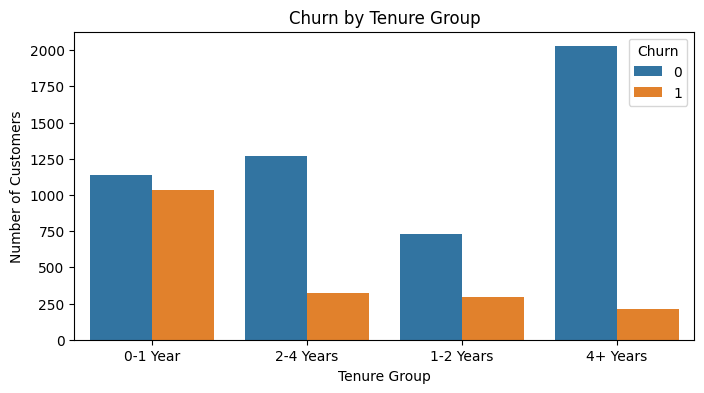

In [21]:
plt.figure(figsize=(8,4))

sns.countplot(x='TenureGroup', hue='Churn', data=df)

plt.title('Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')

plt.show()

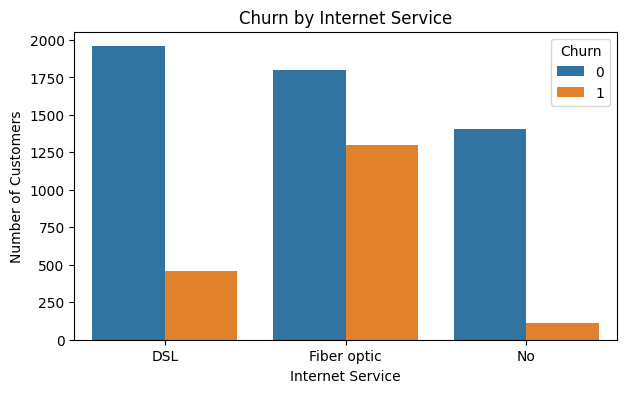

In [22]:
plt.figure(figsize=(7,4))

sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

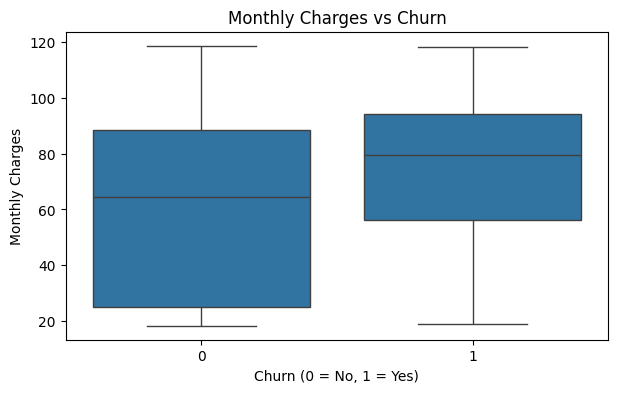

In [23]:
plt.figure(figsize=(7,4))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')

plt.show()

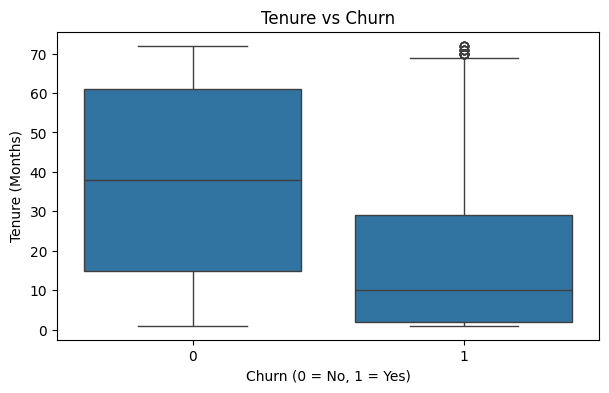

In [24]:
plt.figure(figsize=(7,4))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Tenure vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (Months)')

plt.show()

In [25]:
contract_churn = df.groupby('Contract')['Churn'].mean() * 100

print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


In [26]:
tenure_churn = df.groupby('TenureGroup')['Churn'].mean() * 100

print(tenure_churn)

TenureGroup
0-1 Year     47.678161
1-2 Years    28.710938
2-4 Years    20.388959
4+ Years      9.513176
Name: Churn, dtype: float64


In [27]:
churn_rate = df['Churn'].mean() * 100

print("Overall Churn Rate:", round(churn_rate, 2), "%")

Overall Churn Rate: 26.58 %


In [28]:
gender_churn = df.groupby('gender')['Churn'].mean() * 100

print(gender_churn)

gender
Female    26.959518
Male      26.204565
Name: Churn, dtype: float64


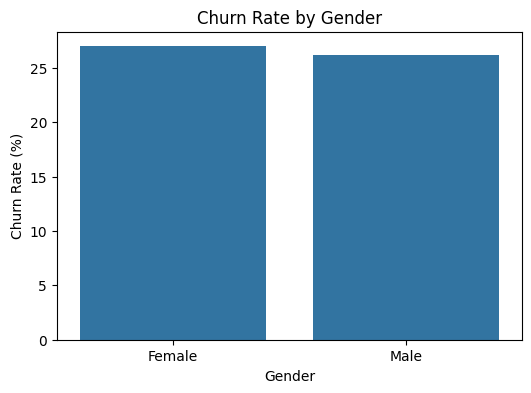

In [29]:
plt.figure(figsize=(6,4))

sns.barplot(x=gender_churn.index, y=gender_churn.values)

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

plt.show()

In [30]:
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100

print(senior_churn)

SeniorCitizen
0    23.650255
1    41.681261
Name: Churn, dtype: float64


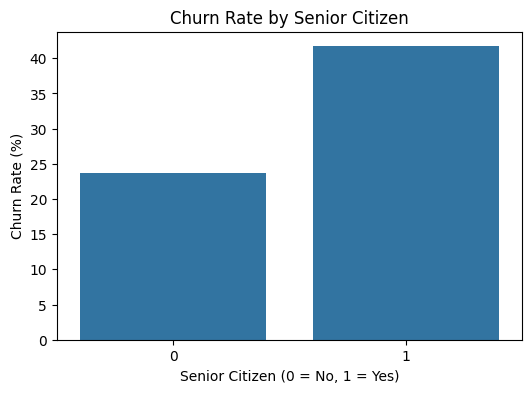

In [31]:
plt.figure(figsize=(6,4))

sns.barplot(x=senior_churn.index, y=senior_churn.values)

plt.title('Churn Rate by Senior Citizen')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')

plt.show()

In [32]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100

print(payment_churn.sort_values(ascending=False))

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64


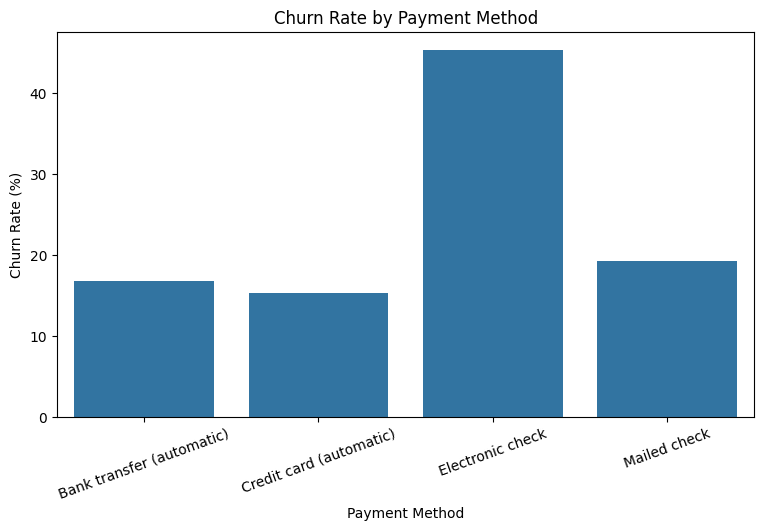

In [33]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)

plt.show()

In [34]:
security_churn = df.groupby('OnlineSecurity')['Churn'].mean() * 100

print(security_churn.sort_values(ascending=False))

OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn, dtype: float64


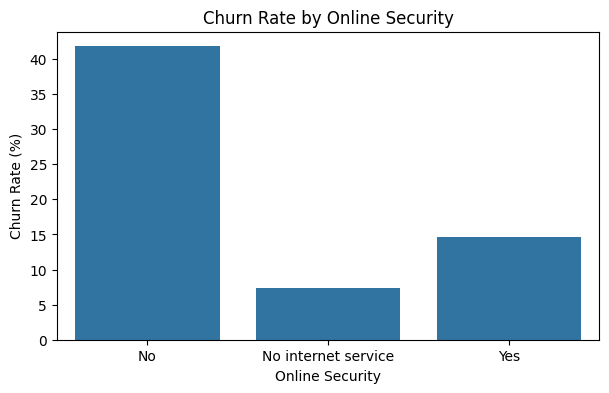

In [35]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=security_churn.index,
    y=security_churn.values
)

plt.title('Churn Rate by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Churn Rate (%)')

plt.show()

In [36]:
techsupport_churn = df.groupby('TechSupport')['Churn'].mean() * 100

print(techsupport_churn.sort_values(ascending=False))

TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn, dtype: float64


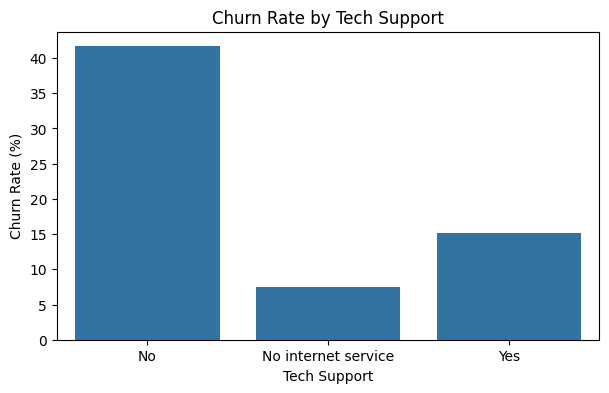

In [37]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=techsupport_churn.index,
    y=techsupport_churn.values
)

plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate (%)')

plt.show()

In [38]:
def charge_group(charge):
    if charge < 40:
        return 'Low'
    elif charge < 70:
        return 'Medium'
    else:
        return 'High'

df['MonthlyChargeGroup'] = df['MonthlyCharges'].apply(charge_group)

In [39]:
charge_churn = df.groupby('MonthlyChargeGroup')['Churn'].mean() * 100

print(charge_churn.sort_values(ascending=False))

MonthlyChargeGroup
High      35.497353
Medium    23.697270
Low       11.632987
Name: Churn, dtype: float64


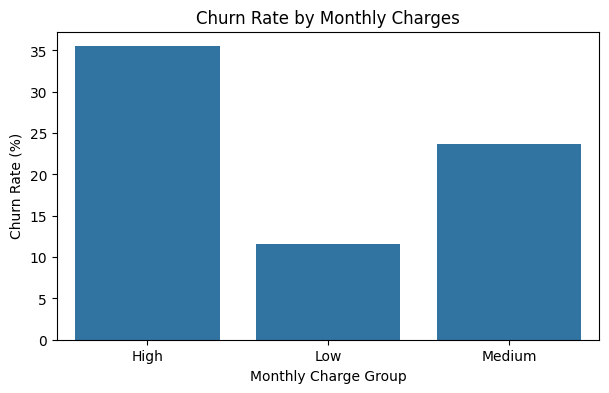

In [40]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=charge_churn.index,
    y=charge_churn.values
)

plt.title('Churn Rate by Monthly Charges')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')

plt.show()

In [41]:
customer_value = df.groupby('Churn')['CustomerValue'].mean()

print(customer_value)

Churn
0    2555.203283
1    1531.608828
Name: CustomerValue, dtype: float64


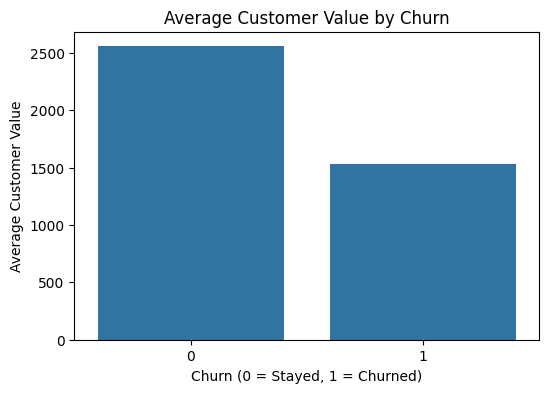

In [42]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=customer_value.index,
    y=customer_value.values
)

plt.title('Average Customer Value by Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Average Customer Value')

plt.show()

In [43]:
numeric_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'CustomerValue',
    'Churn'
]

correlation = df[numeric_cols].corr()

print(correlation)

                  tenure  MonthlyCharges  TotalCharges  CustomerValue  \
tenure          1.000000        0.246862      0.825880       0.826271   
MonthlyCharges  0.246862        1.000000      0.651065       0.651458   
TotalCharges    0.825880        0.651065      1.000000       0.999560   
CustomerValue   0.826271        0.651458      0.999560       1.000000   
Churn          -0.354049        0.192858     -0.199484      -0.199675   

                   Churn  
tenure         -0.354049  
MonthlyCharges  0.192858  
TotalCharges   -0.199484  
CustomerValue  -0.199675  
Churn           1.000000  


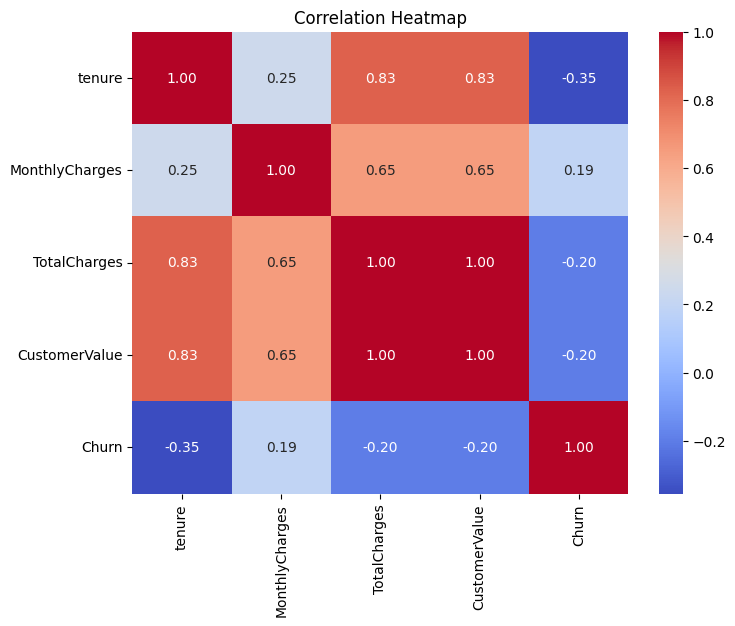

In [44]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [45]:
print("Overall Churn Rate:", round(df['Churn'].mean() * 100, 2), "%")

print("\nChurn by Contract:")
print(df.groupby('Contract')['Churn'].mean().mul(100).round(2))

print("\nChurn by Tenure Group:")
print(df.groupby('TenureGroup')['Churn'].mean().mul(100).round(2))

print("\nChurn by Payment Method:")
print(df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(2))

print("\nChurn by Internet Service:")
print(df.groupby('InternetService')['Churn'].mean().mul(100).round(2))

Overall Churn Rate: 26.58 %

Churn by Contract:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64

Churn by Tenure Group:
TenureGroup
0-1 Year     47.68
1-2 Years    28.71
2-4 Years    20.39
4+ Years      9.51
Name: Churn, dtype: float64

Churn by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Electronic check             45.29
Mailed check                 19.20
Name: Churn, dtype: float64

Churn by Internet Service:
InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64


In [46]:
# Machine learning part
#Select Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 23)
Target shape: (7032,)


In [47]:
#Remove Customer ID
X = X.drop('customerID', axis=1)

print(X.shape)
print(X.columns.tolist())

(7032, 22)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'CustomerValue', 'MonthlyChargeGroup']


In [48]:
# Categorical Encoding
from pandas import get_dummies

In [49]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(7032, 36)


In [50]:
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  CustomerValue  \
0              0       1           29.85         29.85          29.85   
1              0      34           56.95       1889.50        1936.30   
2              0       2           53.85        108.15         107.70   
3              0      45           42.30       1840.75        1903.50   
4              0       2           70.70        151.65         141.40   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0        False         True           False             False   
1         True        False           False              True   
2         True        False           False              True   
3         True        False           False             False   
4        False        False           False              True   

   MultipleLines_No phone service  ...  Contract_Two year  \
0                            True  ...              False   
1                           False  ...          

In [51]:
print(X.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
CustomerValue                            float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [52]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 36)
X_test: (1407, 36)
y_train: (5625,)
y_test: (1407,)


In [55]:
# Feature Scaling
#Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [56]:
# Create the scaler
scaler = StandardScaler()

In [57]:
# Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
#Check the result
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (5625, 36)
Testing data shape: (1407, 36)


In [59]:
# logistic regression
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [60]:
y_pred = logistic_model.predict(X_test_scaled)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0]


In [61]:
#Evaluate Logistic Regression Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [62]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7925
Precision: 0.6314
Recall   : 0.5267
F1 Score : 0.5743
ROC-AUC  : 0.8349


In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



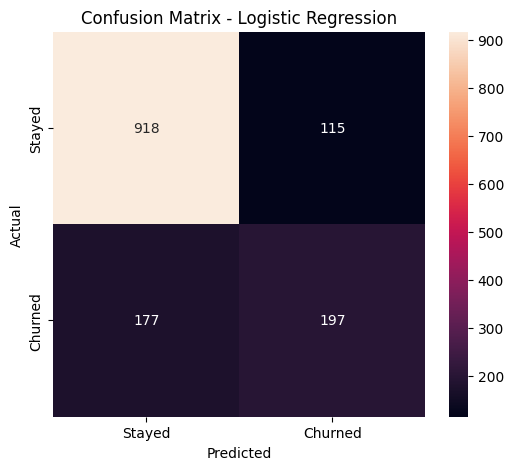

In [64]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [65]:
# Decision Tree
#Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

In [66]:
# Create the model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [67]:
#Train the model
decision_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [68]:
# Make predictions
y_pred_tree = decision_tree.predict(X_test)

In [69]:
#Evaluate the model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1 Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(roc_auc_tree, 4))

Decision Tree Results
--------------------
Accuracy : 0.7783
Precision: 0.5807
Recall   : 0.5963
F1 Score : 0.5884
ROC-AUC  : 0.8195


In [70]:
#Classification report
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



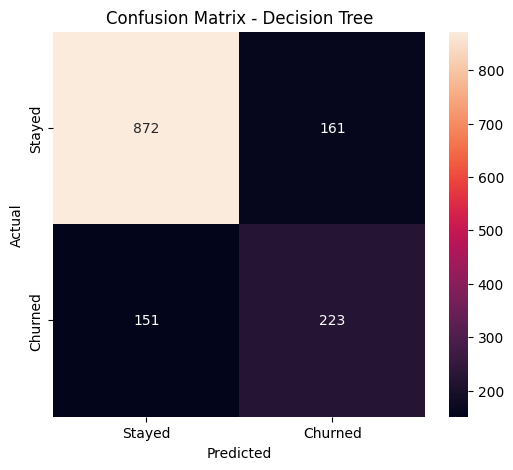

In [71]:
#Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned']
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [72]:
# import random forest
from sklearn.ensemble import RandomForestClassifier

In [73]:
#Create the model
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

In [74]:
#Train the model
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [75]:
# Make predictions
y_pred_rf = random_forest.predict(X_test)

In [76]:
#Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Results
--------------------
Accuracy : 0.7704
Precision: 0.5578
Recall   : 0.6578
F1 Score : 0.6037
ROC-AUC  : 0.8217


In [77]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.66      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.79      0.77      0.78      1407



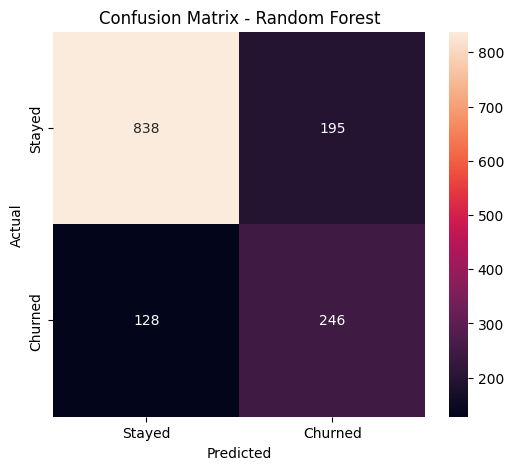

In [78]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [79]:
#Install XGBoost
#XGBoost is a powerful boosting algorithm and is commonly used for classification problems.
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
#Import XGBoost
from xgboost import XGBClassifier

In [81]:
#Create the model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

In [82]:
#Train the model
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [83]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

In [84]:
#Evaluate XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))
print("ROC-AUC  :", round(roc_auc_xgb, 4))

XGBoost Results
----------------
Accuracy : 0.7882
Precision: 0.6188
Recall   : 0.5294
F1 Score : 0.5706
ROC-AUC  : 0.836


In [85]:
#Classification Report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



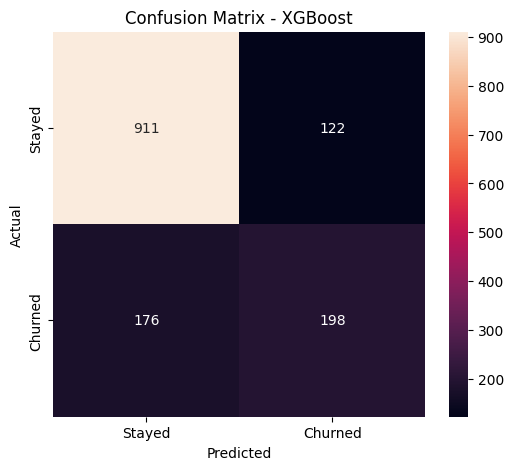

In [86]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned']
)

plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [87]:
# Model Comparison
# Now we compare the 4 models we trained:
#Logistic Regression
#Decision Tree
#Random Forest
#XGBoost
#This helps us choose the best model.

In [88]:
#1. Create comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy,
        accuracy_tree,
        accuracy_rf,
        accuracy_xgb
    ],
    'Precision': [
        precision,
        precision_tree,
        precision_rf,
        precision_xgb
    ],
    'Recall': [
        recall,
        recall_tree,
        recall_rf,
        recall_xgb
    ],
    'F1 Score': [
        f1,
        f1_tree,
        f1_rf,
        f1_xgb
    ],
    'ROC-AUC': [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

print(model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7925     0.6314  0.5267    0.5743   0.8349
1        Decision Tree    0.7783     0.5807  0.5963    0.5884   0.8195
2        Random Forest    0.7704     0.5578  0.6578    0.6037   0.8217
3              XGBoost    0.7882     0.6188  0.5294    0.5706   0.8360


In [89]:
# Sort by ROC-AUC
model_comparison.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.788202,0.618750,0.529412,0.570605,0.835999
0,Logistic Regression,0.792466,0.631410,0.526738,0.574344,0.834857
2,Random Forest,0.770434,0.557823,0.657754,0.603681,0.821699
1,Decision Tree,0.778252,0.580729,0.596257,0.588391,0.819510


In [90]:
#Display as percentages
comparison_percent = model_comparison.copy()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

comparison_percent[metrics] = (
    comparison_percent[metrics] * 100
).round(2)

print(comparison_percent)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     79.25      63.14   52.67     57.43    83.49
1        Decision Tree     77.83      58.07   59.63     58.84    81.95
2        Random Forest     77.04      55.78   65.78     60.37    82.17
3              XGBoost     78.82      61.88   52.94     57.06    83.60


In [91]:
# Identify the best model
best_model_name = model_comparison.loc[
    model_comparison['ROC-AUC'].idxmax(),
    'Model'
]

print("Best Model based on ROC-AUC:", best_model_name)

Best Model based on ROC-AUC: XGBoost


In [92]:
#Feature Importance
#Now we'll find which features are most important for predicting customer churn.
#Since we have trained Random Forest and XGBoost, let's start with Random Forest.

In [93]:
#Get Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                           Feature  Importance
3                     TotalCharges    0.131603
1                           tenure    0.128386
4                    CustomerValue    0.125960
2                   MonthlyCharges    0.122519
26               Contract_Two year    0.058187
11     InternetService_Fiber optic    0.039079
29  PaymentMethod_Electronic check    0.036086
25               Contract_One year    0.026716
5                      gender_Male    0.022652
14              OnlineSecurity_Yes    0.021299
27            PaperlessBilling_Yes    0.020997
20                 TechSupport_Yes    0.018786
6                      Partner_Yes    0.018460
33            TenureGroup_4+ Years    0.018304
16                OnlineBackup_Yes    0.018038


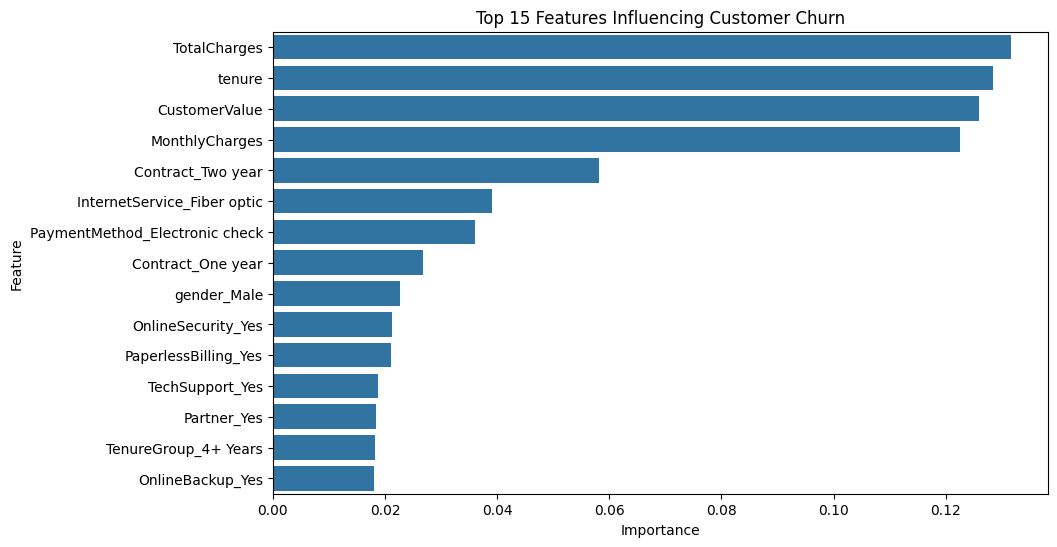

In [94]:
#Visualize Feature Importance
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Features Influencing Customer Churn')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [95]:
#XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

print(xgb_importance.head(15))

                           Feature  Importance
11     InternetService_Fiber optic    0.250753
26               Contract_Two year    0.201356
25               Contract_One year    0.191982
12              InternetService_No    0.057883
1                           tenure    0.050316
24             StreamingMovies_Yes    0.025357
14              OnlineSecurity_Yes    0.022600
29  PaymentMethod_Electronic check    0.017956
20                 TechSupport_Yes    0.015729
27            PaperlessBilling_Yes    0.015453
10               MultipleLines_Yes    0.013597
8                 PhoneService_Yes    0.012089
22                 StreamingTV_Yes    0.012065
3                     TotalCharges    0.010007
4                    CustomerValue    0.009905


In [96]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
#Run this first
import shap
import numpy as np

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [98]:
#Create the explainer again
explainer = shap.TreeExplainer(random_forest)

In [99]:
#Use the newer SHAP method
shap_values = explainer(X_test)

In [100]:
print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(1407, 36, 2)


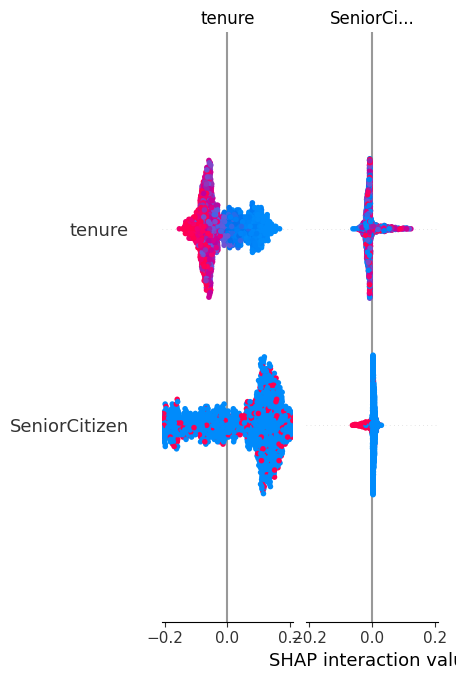

In [101]:
#Create the SHAP summary plot
shap.summary_plot(shap_values, X_test)

In [102]:
# Explain One Customer
customer_index = 0

customer = X_test.iloc[[customer_index]]

print(customer)

     SeniorCitizen  tenure  MonthlyCharges  TotalCharges  CustomerValue  \
974              0      59           75.95       4542.35        4481.05   

     gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
974        False         True            True              True   

     MultipleLines_No phone service  ...  Contract_Two year  \
974                           False  ...               True   

     PaperlessBilling_Yes  PaymentMethod_Credit card (automatic)  \
974                  True                                   True   

     PaymentMethod_Electronic check  PaymentMethod_Mailed check  \
974                           False                       False   

     TenureGroup_1-2 Years  TenureGroup_2-4 Years  TenureGroup_4+ Years  \
974                  False                  False                  True   

     MonthlyChargeGroup_Low  MonthlyChargeGroup_Medium  
974                   False                      False  

[1 rows x 36 columns]


In [103]:
churn_probability = random_forest.predict_proba(customer)[0][1]

print("Churn Probability:",
      round(churn_probability * 100, 2), "%")

Churn Probability: 2.5 %


In [104]:
# Calculate Churn Probability
df['ChurnProbability'] = random_forest.predict_proba(X)[:, 1]

print(df[['customerID', 'ChurnProbability']].head(10))

   customerID  ChurnProbability
0  7590-VHVEG             0.415
1  5575-GNVDE             0.020
2  3668-QPYBK             0.965
3  7795-CFOCW             0.025
4  9237-HQITU             0.960
5  9305-CDSKC             1.000
6  1452-KIOVK             0.560
7  6713-OKOMC             0.405
8  7892-POOKP             0.970
9  6388-TABGU             0.130


In [105]:
#Create Risk Categories
def risk_category(prob):
    if prob > 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['RiskCategory'] = df['ChurnProbability'].apply(risk_category)

print(df[['customerID', 'ChurnProbability', 'RiskCategory']].head(10))

   customerID  ChurnProbability RiskCategory
0  7590-VHVEG             0.415  Medium Risk
1  5575-GNVDE             0.020     Low Risk
2  3668-QPYBK             0.965    High Risk
3  7795-CFOCW             0.025     Low Risk
4  9237-HQITU             0.960    High Risk
5  9305-CDSKC             1.000    High Risk
6  1452-KIOVK             0.560  Medium Risk
7  6713-OKOMC             0.405  Medium Risk
8  7892-POOKP             0.970    High Risk
9  6388-TABGU             0.130     Low Risk


In [106]:
#Calculate Revenue at Risk
df['RevenueAtRisk'] = df['MonthlyCharges'] * df['ChurnProbability']

print(df[['customerID', 'MonthlyCharges', 'ChurnProbability', 'RevenueAtRisk']].head(10))

   customerID  MonthlyCharges  ChurnProbability  RevenueAtRisk
0  7590-VHVEG           29.85             0.415       12.38775
1  5575-GNVDE           56.95             0.020        1.13900
2  3668-QPYBK           53.85             0.965       51.96525
3  7795-CFOCW           42.30             0.025        1.05750
4  9237-HQITU           70.70             0.960       67.87200
5  9305-CDSKC           99.65             1.000       99.65000
6  1452-KIOVK           89.10             0.560       49.89600
7  6713-OKOMC           29.75             0.405       12.04875
8  7892-POOKP          104.80             0.970      101.65600
9  6388-TABGU           56.15             0.130        7.29950


In [107]:
# Check Risk Distribution
print(df['RiskCategory'].value_counts())

RiskCategory
Low Risk       4782
High Risk      1729
Medium Risk     521
Name: count, dtype: int64


In [108]:
print(
    df.groupby('RiskCategory')['RevenueAtRisk']
      .sum()
      .sort_values(ascending=False)
)

RiskCategory
High Risk      119908.740567
Low Risk        39169.273598
Medium Risk     19191.093709
Name: RevenueAtRisk, dtype: float64


In [109]:
# Find Top High-Risk Customers
high_risk_customers = df[
    df['RiskCategory'] == 'High Risk'
].sort_values(
    'ChurnProbability',
    ascending=False
)

print(
    high_risk_customers[
        [
            'customerID',
            'Contract',
            'tenure',
            'MonthlyCharges',
            'ChurnProbability',
            'RiskCategory',
            'RevenueAtRisk'
        ]
    ].head(10)
)

      customerID        Contract  tenure  MonthlyCharges  ChurnProbability  \
5     9305-CDSKC  Month-to-month       8           99.65               1.0   
1651  8580-AECUZ  Month-to-month       1           79.10               1.0   
1731  8375-DKEBR  Month-to-month       1           69.60               1.0   
1739  9804-ICWBG  Month-to-month       1           69.90               1.0   
6660  1447-GIQMR  Month-to-month       1           69.15               1.0   
207   1285-OKIPP  Month-to-month       1           79.90               1.0   
6764  7660-HDPJV  Month-to-month       1           69.20               1.0   
6789  7839-QRKXN  Month-to-month       1           20.20               1.0   
6816  2446-PLQVO  Month-to-month       1           70.30               1.0   
1976  9497-QCMMS  Month-to-month       1           93.55               1.0   

     RiskCategory  RevenueAtRisk  
5       High Risk          99.65  
1651    High Risk          79.10  
1731    High Risk          69.60  
1

In [110]:
# Save the Scored Dataset
df.to_csv('customer_churn_scored.csv', index=False)

print("Scored dataset saved successfully!")

Scored dataset saved successfully!


In [111]:
#Create Retention Recommendation
def retention_recommendation(row):

    if row['RiskCategory'] == 'High Risk':
        
        if row['Contract'] == 'Month-to-month':
            return 'Offer long-term contract discount'
        
        elif row['MonthlyCharges'] >= 70:
            return 'Offer personalized pricing/discount'
        
        elif row['TechSupport'] == 'No':
            return 'Offer free Tech Support'
        
        elif row['OnlineSecurity'] == 'No':
            return 'Offer Online Security package'
        
        else:
            return 'Contact customer with retention offer'

    elif row['RiskCategory'] == 'Medium Risk':
        return 'Send targeted retention promotion'

    else:
        return 'Continue regular engagement'


df['RetentionRecommendation'] = df.apply(
    retention_recommendation,
    axis=1
)

print(
    df[
        [
            'customerID',
            'RiskCategory',
            'ChurnProbability',
            'RetentionRecommendation'
        ]
    ].head(10)
)

   customerID RiskCategory  ChurnProbability  \
0  7590-VHVEG  Medium Risk             0.415   
1  5575-GNVDE     Low Risk             0.020   
2  3668-QPYBK    High Risk             0.965   
3  7795-CFOCW     Low Risk             0.025   
4  9237-HQITU    High Risk             0.960   
5  9305-CDSKC    High Risk             1.000   
6  1452-KIOVK  Medium Risk             0.560   
7  6713-OKOMC  Medium Risk             0.405   
8  7892-POOKP    High Risk             0.970   
9  6388-TABGU     Low Risk             0.130   

             RetentionRecommendation  
0  Send targeted retention promotion  
1        Continue regular engagement  
2  Offer long-term contract discount  
3        Continue regular engagement  
4  Offer long-term contract discount  
5  Offer long-term contract discount  
6  Send targeted retention promotion  
7  Send targeted retention promotion  
8  Offer long-term contract discount  
9        Continue regular engagement  


In [112]:
# Check Recommendations
print(df['RetentionRecommendation'].value_counts())

RetentionRecommendation
Continue regular engagement              4782
Offer long-term contract discount        1561
Send targeted retention promotion         521
Offer personalized pricing/discount       130
Offer free Tech Support                    18
Contact customer with retention offer      14
Offer Online Security package               6
Name: count, dtype: int64


In [113]:
#Find High-Risk Customers + Actions
high_risk = df[
    df['RiskCategory'] == 'High Risk'
].sort_values(
    'ChurnProbability',
    ascending=False
)

print(
    high_risk[
        [
            'customerID',
            'Contract',
            'tenure',
            'MonthlyCharges',
            'ChurnProbability',
            'RevenueAtRisk',
            'RetentionRecommendation'
        ]
    ].head(20)
)

      customerID        Contract  tenure  MonthlyCharges  ChurnProbability  \
5     9305-CDSKC  Month-to-month       8           99.65               1.0   
1651  8580-AECUZ  Month-to-month       1           79.10               1.0   
1731  8375-DKEBR  Month-to-month       1           69.60               1.0   
1739  9804-ICWBG  Month-to-month       1           69.90               1.0   
6660  1447-GIQMR  Month-to-month       1           69.15               1.0   
207   1285-OKIPP  Month-to-month       1           79.90               1.0   
6764  7660-HDPJV  Month-to-month       1           69.20               1.0   
6789  7839-QRKXN  Month-to-month       1           20.20               1.0   
6816  2446-PLQVO  Month-to-month       1           70.30               1.0   
1976  9497-QCMMS  Month-to-month       1           93.55               1.0   
1995  8000-REIQB  Month-to-month       1           69.95               1.0   
2033  8305-VHZBZ  Month-to-month       1           20.20        

In [114]:
#Save Final Dataset
df.to_csv(
    'customer_churn_final.csv',
    index=False
)

print("Final customer churn dataset saved successfully!")

Final customer churn dataset saved successfully!


In [116]:
import os

print(os.getcwd())

C:\Users\Ruchita


In [117]:
check_df = pd.read_csv('customer_churn_final.csv')

print(check_df.shape)
print(check_df.columns.tolist())
print(check_df.head())

(7032, 28)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'CustomerValue', 'MonthlyChargeGroup', 'ChurnProbability', 'RiskCategory', 'RevenueAtRisk', 'RetentionRecommendation']
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity

In [118]:
df.to_csv('customer_churn_final.csv', index=False)
print("File saved!")

File saved!


In [119]:
import os
print(os.getcwd())

C:\Users\Ruchita


In [120]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'CustomerValue', 'MonthlyChargeGroup', 'ChurnProbability', 'RiskCategory', 'RevenueAtRisk', 'RetentionRecommendation']
